Number of input files: 416484
Number of output files: 416484


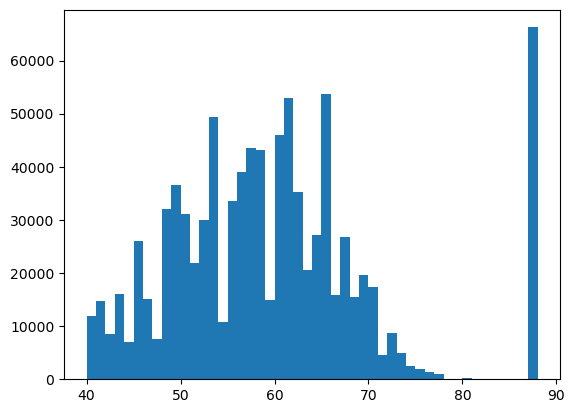

In [3]:
import numpy as np
import os,glob
import matplotlib.pyplot as plt
# input_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/input'
# output_data_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/output'

training_dir = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training'
subset = '/home/gerald/workspace/src/GuitarMidi-LV2/python/neuralnetmodelling/data_slices/training_subset'

input_filepaths = []#sorted(glob.glob(os.path.join(input_data_dir, '*.npy')))
output_filepaths = sorted(glob.glob(os.path.join(training_dir, '**', 'output', '*.npy'), recursive=True))

for output_filepath in output_filepaths:
    
    parentdir=os.path.dirname(os.path.dirname(output_filepath))
    filename=os.path.basename(output_filepath)
   
    inputfile=os.path.join(parentdir,'input',filename)
    # print(inputfile)
    input_filepaths.append(inputfile)

print(f'Number of input files: {len(input_filepaths)}')
print(f'Number of output files: {len(output_filepaths)}')

def midi_hist(output_filepaths):
    hist =[]# np.zeros((89,), dtype=int)
    for output_filepath in output_filepaths:
        output_data = np.load(output_filepath)
        for frame in output_data:
            for note in range(89):
                if frame[note] == 1:
                    hist.append(note)
    plt.hist(hist,range(40,89))
  

midi_hist(output_filepaths)





In [4]:
# The limit of samples with midi notes off to be put into the trainingset
sailent_thresh=8000 
current_sailent_count=np.zeros(89,dtype=int)
selected_outfiles=[]
selected_infiles=[]
 
rng=np.random.default_rng(123)
perm=rng.permutation(len(output_filepaths))
output_filepaths=[output_filepaths[i] for i in perm]
input_filepaths=[input_filepaths[i] for i in perm]
# for i,output_filepath in enumerate(output_filepaths):
#     output_data=np.load(output_filepath)


    # # print(output_data.shape)
    # # print("out path:", output_filepath)
    # # print("in path:", input_filepaths[i])
    # if output_data[0][88]>0:
    #     if current_sailent_count[88]<sailent_thresh:
    #         selected_outfiles.append(output_filepath)
    #         selected_infiles.append(input_filepaths[i])
    #         current_sailent_count[88]+=1
    # else:
    #     selected_outfiles.append(output_filepath)
    #     selected_infiles.append(input_filepaths[i])


for i,output_filepath in enumerate(output_filepaths):
    output_data=np.load(output_filepath)
    copydata=True
    for note in range(89):
        if output_data[0][note]>0:
            if current_sailent_count[note]>sailent_thresh:
                copydata=False

    # print(output_data.shape)
    # print("out path:", output_filepath)
    # print("in path:", input_filepaths[i])

    if copydata:
        selected_outfiles.append(output_filepath)
        selected_infiles.append(input_filepaths[i])
        for note in range(89):
            if output_data[0][note]>0:
                current_sailent_count[note]+=1
   


Selected files count: 135726
Final midi hist:


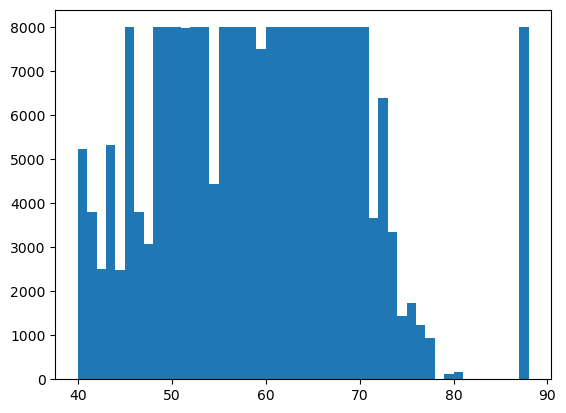

In [8]:
import shutil



# os.makedirs(trin,exist_ok=True)
print("Selected files count:",len(selected_outfiles))
for i,output_filepath in enumerate(selected_outfiles):
   
    output_filename=os.path.basename(output_filepath)
    input_filename=os.path.basename(selected_infiles[i])
    parentdir=os.path.dirname(os.path.dirname(output_filepath))
    destin_dir=os.path.join(subset,os.path.basename(parentdir))
    os.makedirs(destin_dir,exist_ok=True)
    trin=os.path.join(destin_dir,'input')
    trout=os.path.join(destin_dir,'output')
    os.makedirs(trin,exist_ok=True)
    os.makedirs(trout,exist_ok=True)
    fout=os.path.join(trout,output_filename)
    fin=os.path.join(trin,input_filename)
    # print('Copying ',output_filepath,' to ',fout)
    shutil.copyfile(output_filepath,fout)
    
    # print('Copying ',selected_infiles[i],' to ',fin)
    shutil.copyfile(selected_infiles[i],fin)
    

print("Final midi hist:")
output_filepaths = sorted(glob.glob(os.path.join(subset, '**', 'output', '*.npy'), recursive=True))
midi_hist(output_filepaths)


